In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

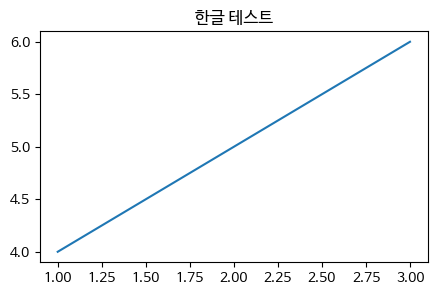

In [39]:
!apt-get -qq -y install fonts-nanum > /dev/null

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

fm.fontManager.addfont(font_path)

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(5, 3))
plt.title('한글 테스트')
plt.plot([1, 2, 3], [4, 5, 6])
plt.show()

In [40]:
df = pd.read_csv('/kaggle/input/datasets/summerhack/encar-data/encar_data.csv')

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139020 entries, 0 to 139019
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Id               139020 non-null  int64  
 1   HomeService      55593 non-null   object 
 2   EncarDiagnosis   119354 non-null  object 
 3   Manufacturer     139020 non-null  object 
 4   Model            139020 non-null  object 
 5   Badge            139020 non-null  object 
 6   Transmission     139020 non-null  object 
 7   FuelType         139020 non-null  object 
 8   Year             139020 non-null  float64
 9   Mileage          139020 non-null  float64
 10  Price            139020 non-null  float64
 11  SellType         139020 non-null  object 
 12  OfficeCityState  139020 non-null  object 
 13  OfficeName       138043 non-null  object 
dtypes: float64(3), int64(1), object(10)
memory usage: 14.8+ MB


In [42]:
df.head()

,Id,HomeService,EncarDiagnosis,Manufacturer,Model,Badge,Transmission,FuelType,Year,Mileage,Price,SellType,OfficeCityState,OfficeName
0,41608078,EncarMeetgo,EncarDiagnosisP1,쉐보레(GM대우),더 뉴 트랙스,1.4 프리미어,오토,가솔린,202003.0,72189.0,9999.0,일반,인천,용일상사
1,40929662,EncarMeetgo,EncarDiagnosisP1,현대,스타리아,4WD 라운지 7인승,오토,디젤,202310.0,4629.0,4290.0,일반,부산,주식회사 라임모터스
2,41593118,EncarMeetgo,EncarDiagnosisP1,쉐보레(GM대우),아베오 해치백,LS,오토,가솔린,201407.0,37230.0,400.0,일반,부산,주식회사 라임모터스
3,40596394,EncarMeetgo,EncarDiagnosisP1,쉐보레(GM대우),올 뉴 말리부,2.0 터보 LTZ,오토,가솔린,201611.0,125969.0,850.0,일반,광주,(주)마이오토
4,41252502,EncarMeetgo,EncarDiagnosisP1,현대,그랜드 스타렉스,11인승 왜건,오토,디젤,201509.0,162475.0,990.0,일반,광주,(주)마이오토


In [43]:
df.drop(['OfficeName'], axis=1, inplace=True)

In [44]:
df.isnull().sum()

Id                     0
HomeService        83427
EncarDiagnosis     19666
Manufacturer           0
Model                  0
Badge                  0
Transmission           0
FuelType               0
Year                   0
Mileage                0
Price                  0
SellType               0
OfficeCityState        0
dtype: int64

In [45]:
# HomeService와 EncarDiagnosis는 Null값 자체로 의미가 있다.
df_copy = df.copy()
df_copy['HomeService'] = df_copy['HomeService'].fillna('None')# ==== Feature Engineering ====(pipeline)
df_copy['EncarDiagnosis'] = df_copy['EncarDiagnosis'].fillna('None')# ====Feature Engineering ====(pipeline)

In [46]:
cat_cols = ['HomeService', 'EncarDiagnosis', 'Manufacturer', 'Model', 'Badge', 'Transmission', 'FuelType', 'SellType', 'OfficeCityState']
num_cols = ['Id', 'Year', 'Mileage', 'Price']

for col in cat_cols:
    print('Number of Unique Categorical Values')
    print(f'=================={col}=================')
    print(df_copy[col].nunique())
    

Number of Unique Categorical Values
==================HomeService=================
2
Number of Unique Categorical Values
==================EncarDiagnosis=================
4
Number of Unique Categorical Values
==================Manufacturer=================
7
Number of Unique Categorical Values
==================Model=================
343
Number of Unique Categorical Values
==================Badge=================
1110
Number of Unique Categorical Values
==================Transmission=================
4
Number of Unique Categorical Values
==================FuelType=================
8
Number of Unique Categorical Values
==================SellType=================
3
Number of Unique Categorical Values
==================OfficeCityState=================
16


In [47]:
# Model칼럼과 Badge칼럼은 카디널리티가 상당히 크게 나오기 때문에 전체 데이터 비율과 비교해 봤을 때 희소 라벨을 가진 데이터는 '기타'로 바꿔준다.

for col in cat_cols:
    print('Value Counts of Categorical Values')
    print(f'==================={col}=================')
    print(df_copy[col].value_counts())
    

Value Counts of Categorical Values
===================HomeService=================
HomeService
None           83427
EncarMeetgo    55593
Name: count, dtype: int64
Value Counts of Categorical Values
===================EncarDiagnosis=================
EncarDiagnosis
EncarDiagnosisP1    78890
EncarDiagnosisP0    33859
None                19666
EncarDiagnosisP2     6605
Name: count, dtype: int64
Value Counts of Categorical Values
===================Manufacturer=================
Manufacturer
기아            53791
현대            46688
제네시스          14488
KG모빌리티(쌍용)     8882
쉐보레(GM대우)      7782
르노코리아(삼성)      7372
기타 제조사           17
Name: count, dtype: int64
Value Counts of Categorical Values
===================Model=================
Model
카니발 4세대      8358
팰리세이드        3895
GV80         3798
쏘렌토 4세대      3685
G80 (RG3)    2718
             ... 
뉴무쏘             1
NF 쏘나타          1
더 뉴 쏘울          1
그랜드 카니발         1
마티즈 클래식         1
Name: count, Length: 343, dtype: int64
Value Counts of Categor

In [48]:
# 차원의 저주 문제를 해결하기 위해 (Badge, Model 칼럼의 희소 라벨을 전처리한다.)
rare_label_index = {}
for col in ['Badge', 'Model']:
    count = df_copy[col].value_counts()
    count = 100 * count / len(df)
    rare_label = count[count < 0.1].index
    rare_label_index[col] = rare_label
    
    df_copy.loc[df_copy[col].isin(rare_label), col] = 'Others' # ==== Feature Engineering ====(nonpipeline)
    

In [49]:
rare_label_index

{'Badge': Index(['1.6 디젤 LTZ', '스탠다드', '1.6 디젤 LT', '2.0 HEV', '3.3T 스포츠 AWD',
        '가솔린 2WD RE', 'PE', 'LPI 디럭스', '4WD RX4', 'HG240 럭셔리',
        ...
        '1.6 디젤 프레스티지', 'LIMITED 리무진 9인승', 'SM520V 플러스', '2WD RS', '이동판매차',
        '3.6 익스트림 2WD', '디젤 1.6 2WD C7', '고급형', '1.6 터보 스타일', '3.3 GT 아크로 에디션'],
       dtype='object', name='Badge', length=915),
 'Model': Index(['i30 (PD)', '렉스턴 W', '슈퍼 렉스턴', '아베오 해치백', 'LF 쏘나타 하이브리드', '볼트 EV',
        '더 뉴 캐스퍼', '스팅어 마이스터', 'i30(신형)', 'K5 하이브리드',
        ...
        '로체 어드밴스', '뉴SM5', '라세티 프리미어', '더 뉴 아베오 해치백', 'NF 쏘나타 트랜스폼', '뉴무쏘',
        'NF 쏘나타', '더 뉴 쏘울', '그랜드 카니발', '마티즈 클래식'],
       dtype='object', name='Model', length=171)}

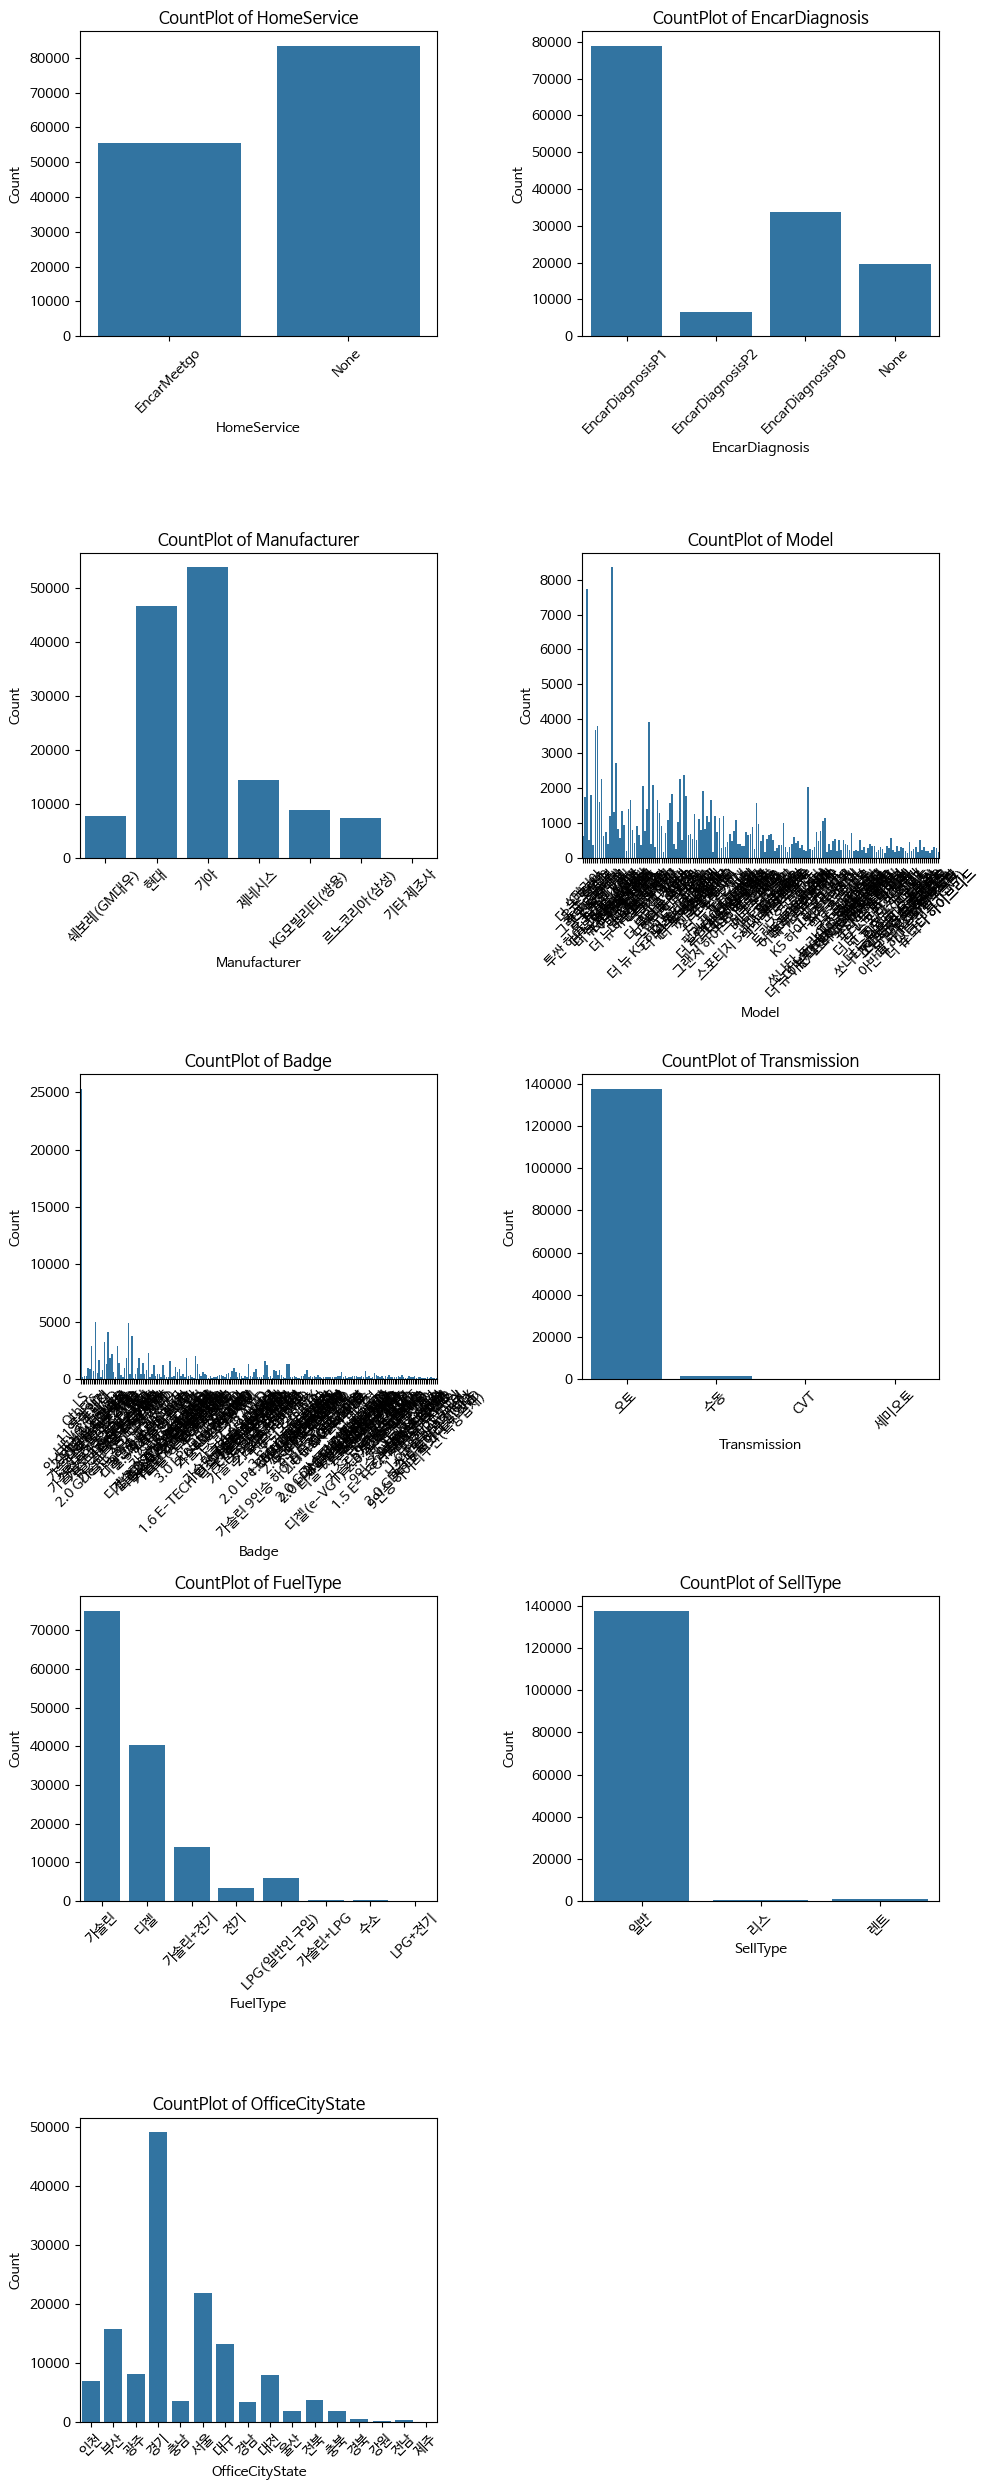

In [50]:
# 범주형 변수의 countplot을 그린다.

plt.figure(figsize=(10, 25))
for i, col in enumerate(cat_cols):
    ax = plt.subplot(5, 2, i+1)
    sns.countplot(data=df_copy, x=col)
    ax.set_title(f'CountPlot of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

(0.0, 10000.0)

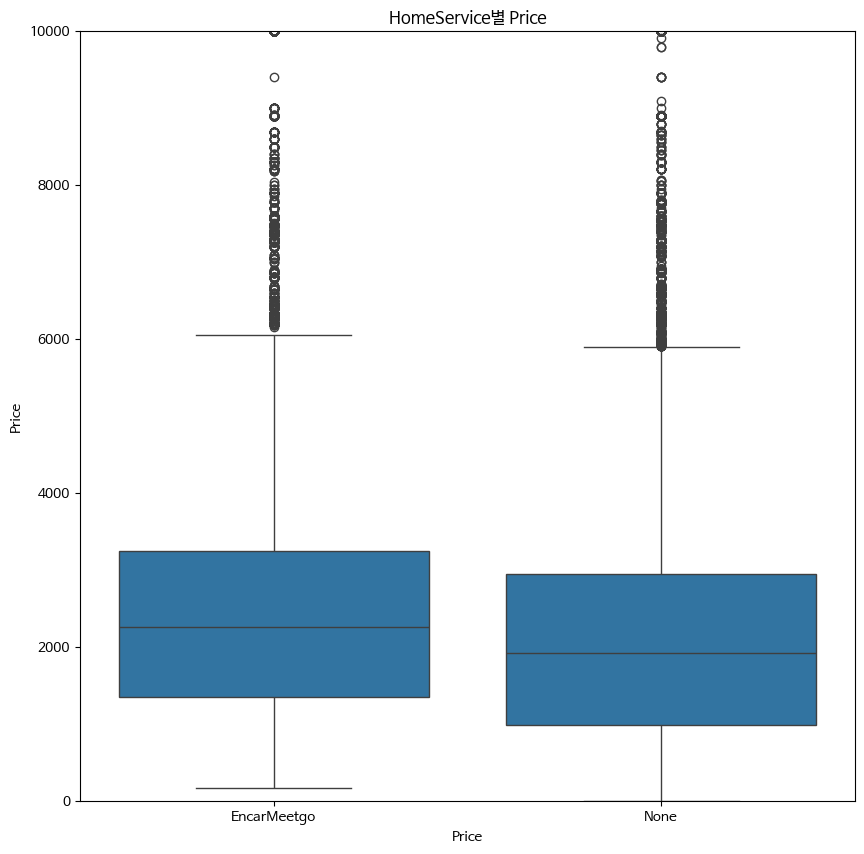

In [51]:
# HomeService별 Price 분포
plt.figure(figsize=(10, 10))
sns.boxplot(data=df_copy, y='Price', x='HomeService')
plt.xlabel('Price')
plt.title('HomeService별 Price')
plt.ylim([0, 10000])

(0.0, 20000.0)

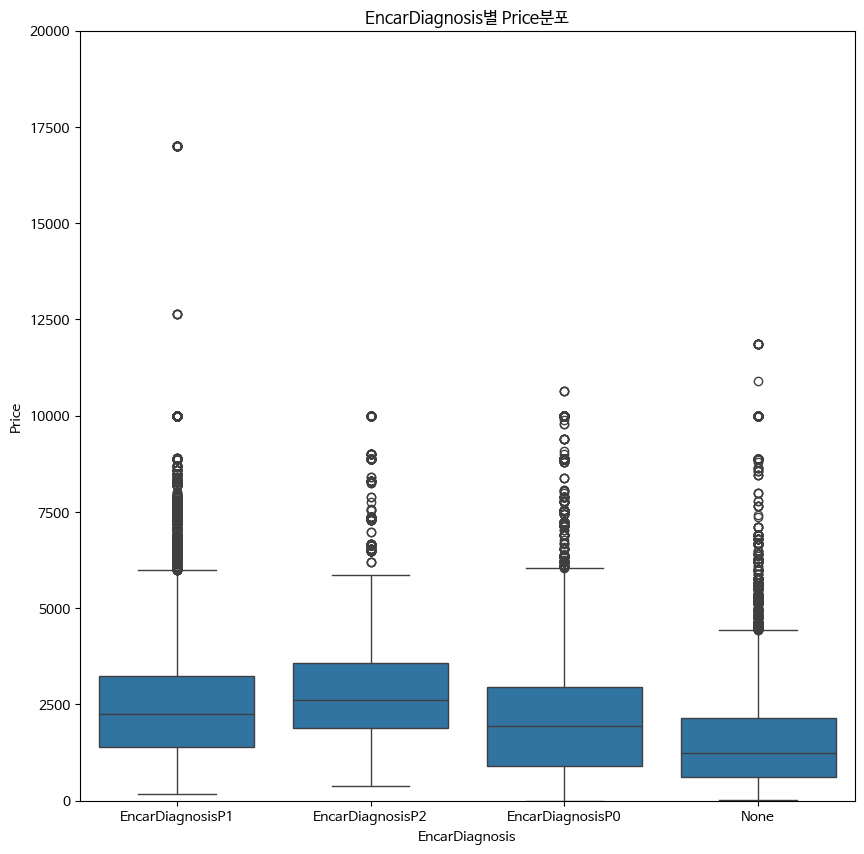

In [52]:
# EncarDiagnosis별 Price분포
plt.figure(figsize=(10, 10))
sns.boxplot(data=df_copy, x='EncarDiagnosis', y='Price')
plt.xlabel('EncarDiagnosis')
plt.title('EncarDiagnosis별 Price분포')
plt.ylim([0, 20000])

(0.0, 20000.0)

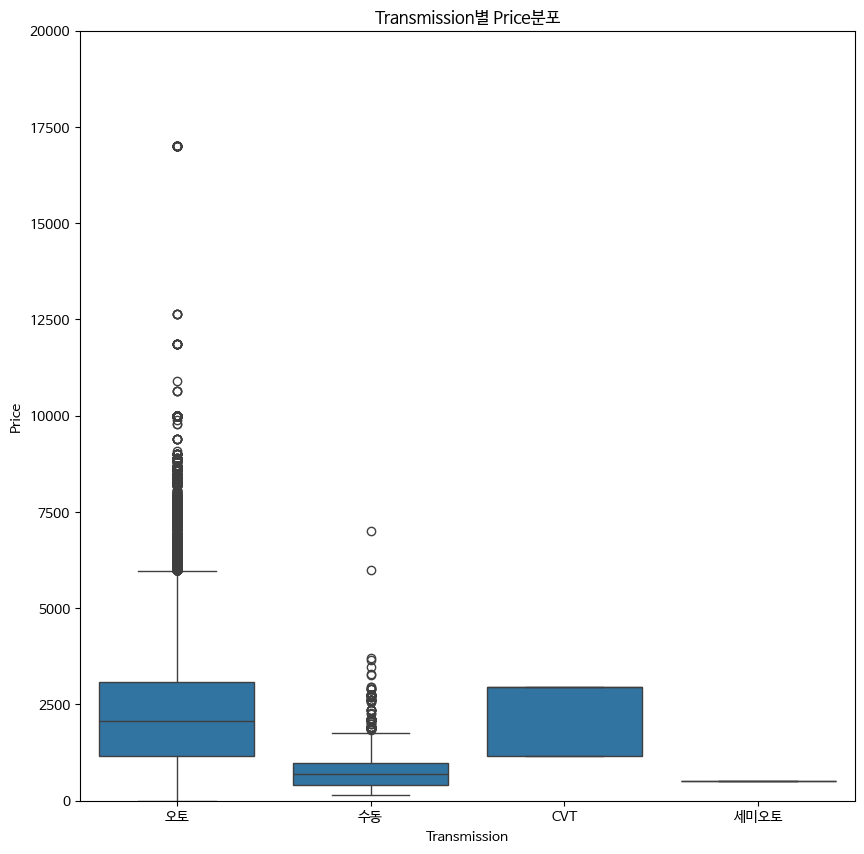

In [53]:
# Transmission별 Price분포
plt.figure(figsize=(10, 10))
sns.boxplot(data=df_copy, x='Transmission', y='Price')
plt.xlabel('Transmission')
plt.title('Transmission별 Price분포')
plt.ylim([0, 20000])

(0.0, 20000.0)

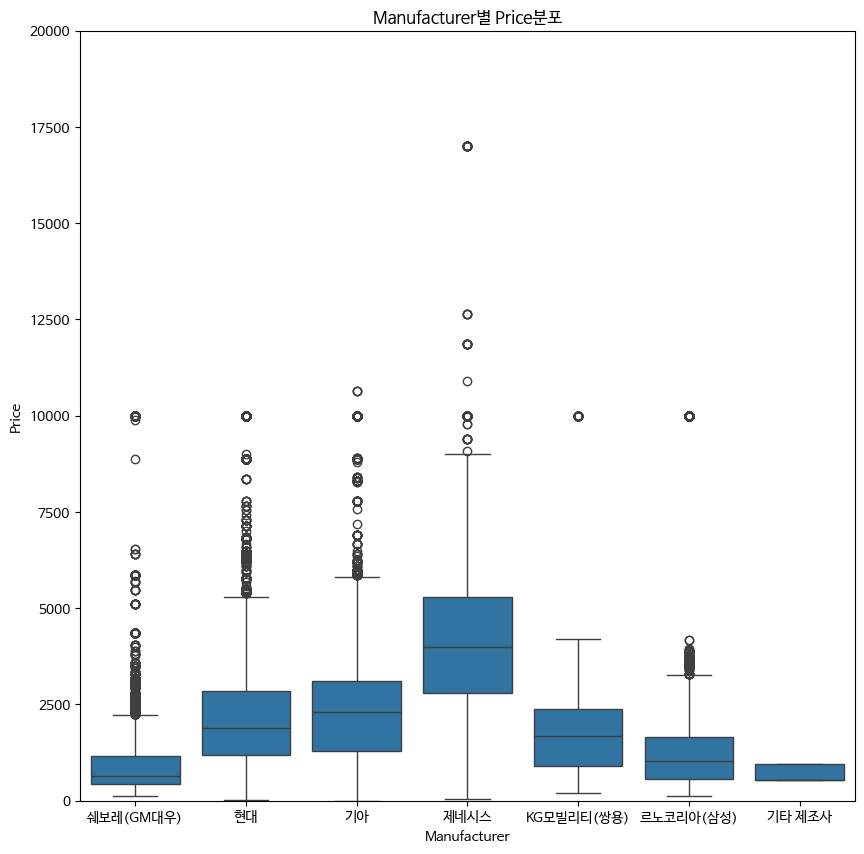

In [54]:
# Manufacturer별 Price분포
plt.figure(figsize=(10, 10))
sns.boxplot(data=df_copy, x='Manufacturer', y='Price')
plt.xlabel('Manufacturer')
plt.title('Manufacturer별 Price분포')
plt.ylim([0, 20000])

(0.0, 20000.0)

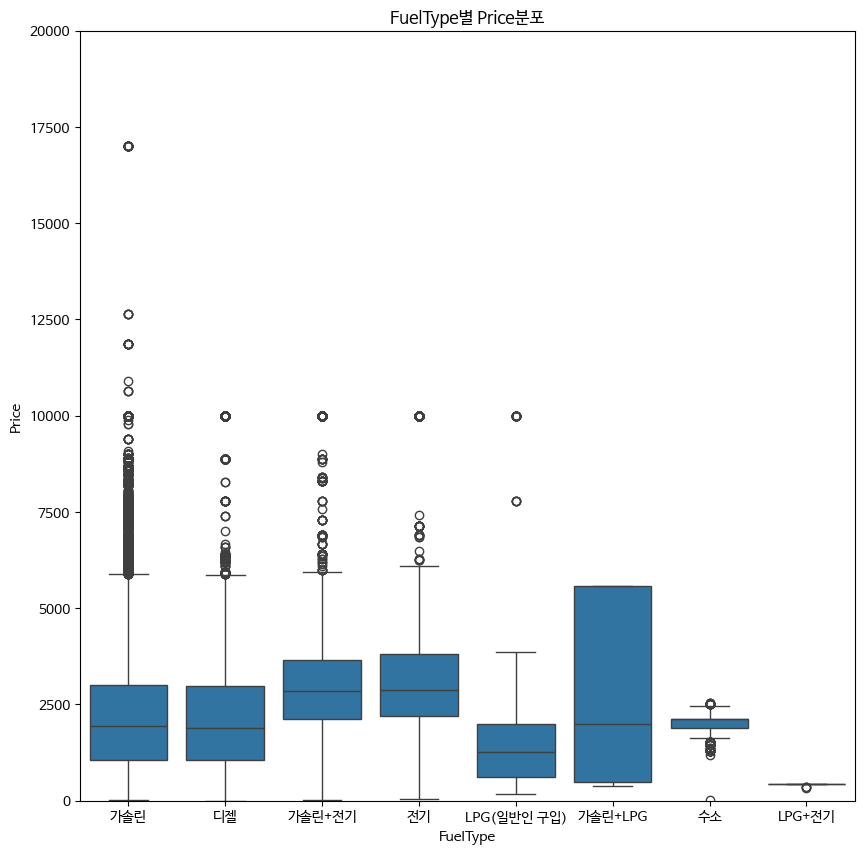

In [55]:
# FuelType별 Price분포
plt.figure(figsize=(10, 10))
sns.boxplot(data=df_copy, x='FuelType', y='Price')
plt.xlabel('FuelType')
plt.title('FuelType별 Price분포')
plt.ylim([0, 20000])

(0.0, 20000.0)

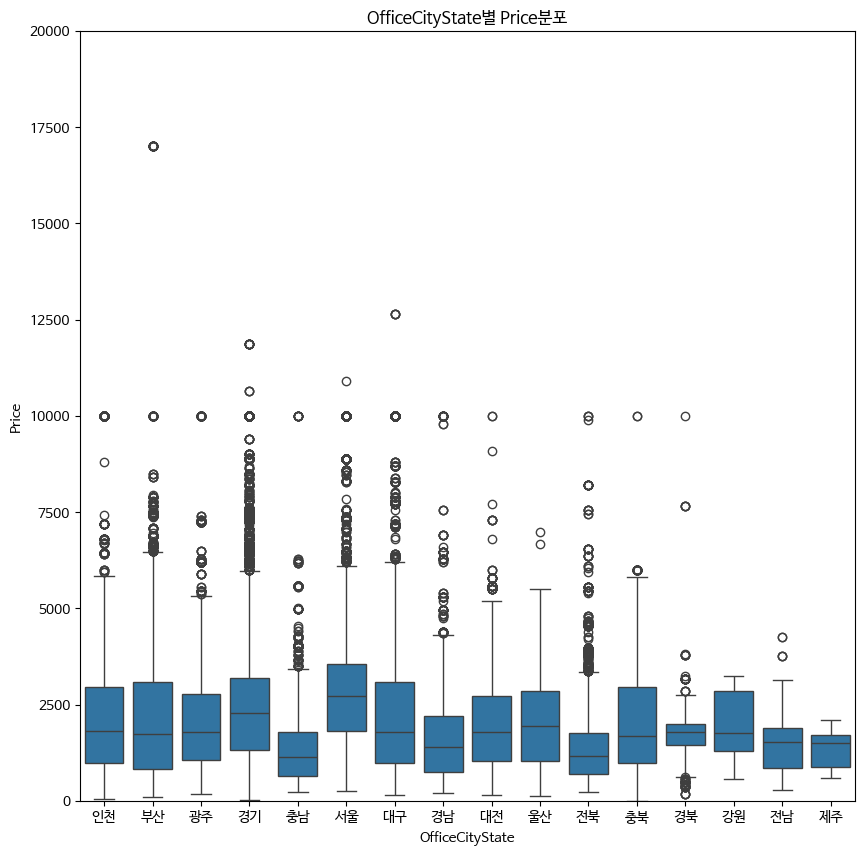

In [56]:
# OfficeCityState별 Price분포
plt.figure(figsize=(10, 10))
sns.boxplot(data=df_copy, x='OfficeCityState', y='Price')
plt.xlabel('OfficeCityState')
plt.title('OfficeCityState별 Price분포')
plt.ylim([0, 20000])

In [57]:
# 카테고리 변수 별 Price의 분포를 확인한 결과 Price의 이상치가 보이기 때문에 이상치를 제거해준다.
df_copy['Price'].describe()

# Price에 99999이라는 말도 안되는 가격이 보인다. IQR방식으로 이상치를 제거한 후 다시 Boxplot을 그려준다.

count    139020.000000
mean       2335.548195
std        1705.610283
min           0.000000
25%        1150.000000
50%        2050.000000
75%        3090.000000
max       99999.000000
Name: Price, dtype: float64

In [58]:
def remove_outliers(df, col):
    df_copy = df.copy()
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df_clean = df_copy[(df_copy[col] >= lower) & (df_copy[col] <= upper)]

    return df_clean

In [59]:
df = df_copy.copy()
df_clean = remove_outliers(df_copy, 'Price')
df_clean['Price'].describe()

count    134796.000000
mean       2145.681496
std        1267.089945
min           0.000000
25%        1100.000000
50%        1990.000000
75%        2950.000000
max        6000.000000
Name: Price, dtype: float64

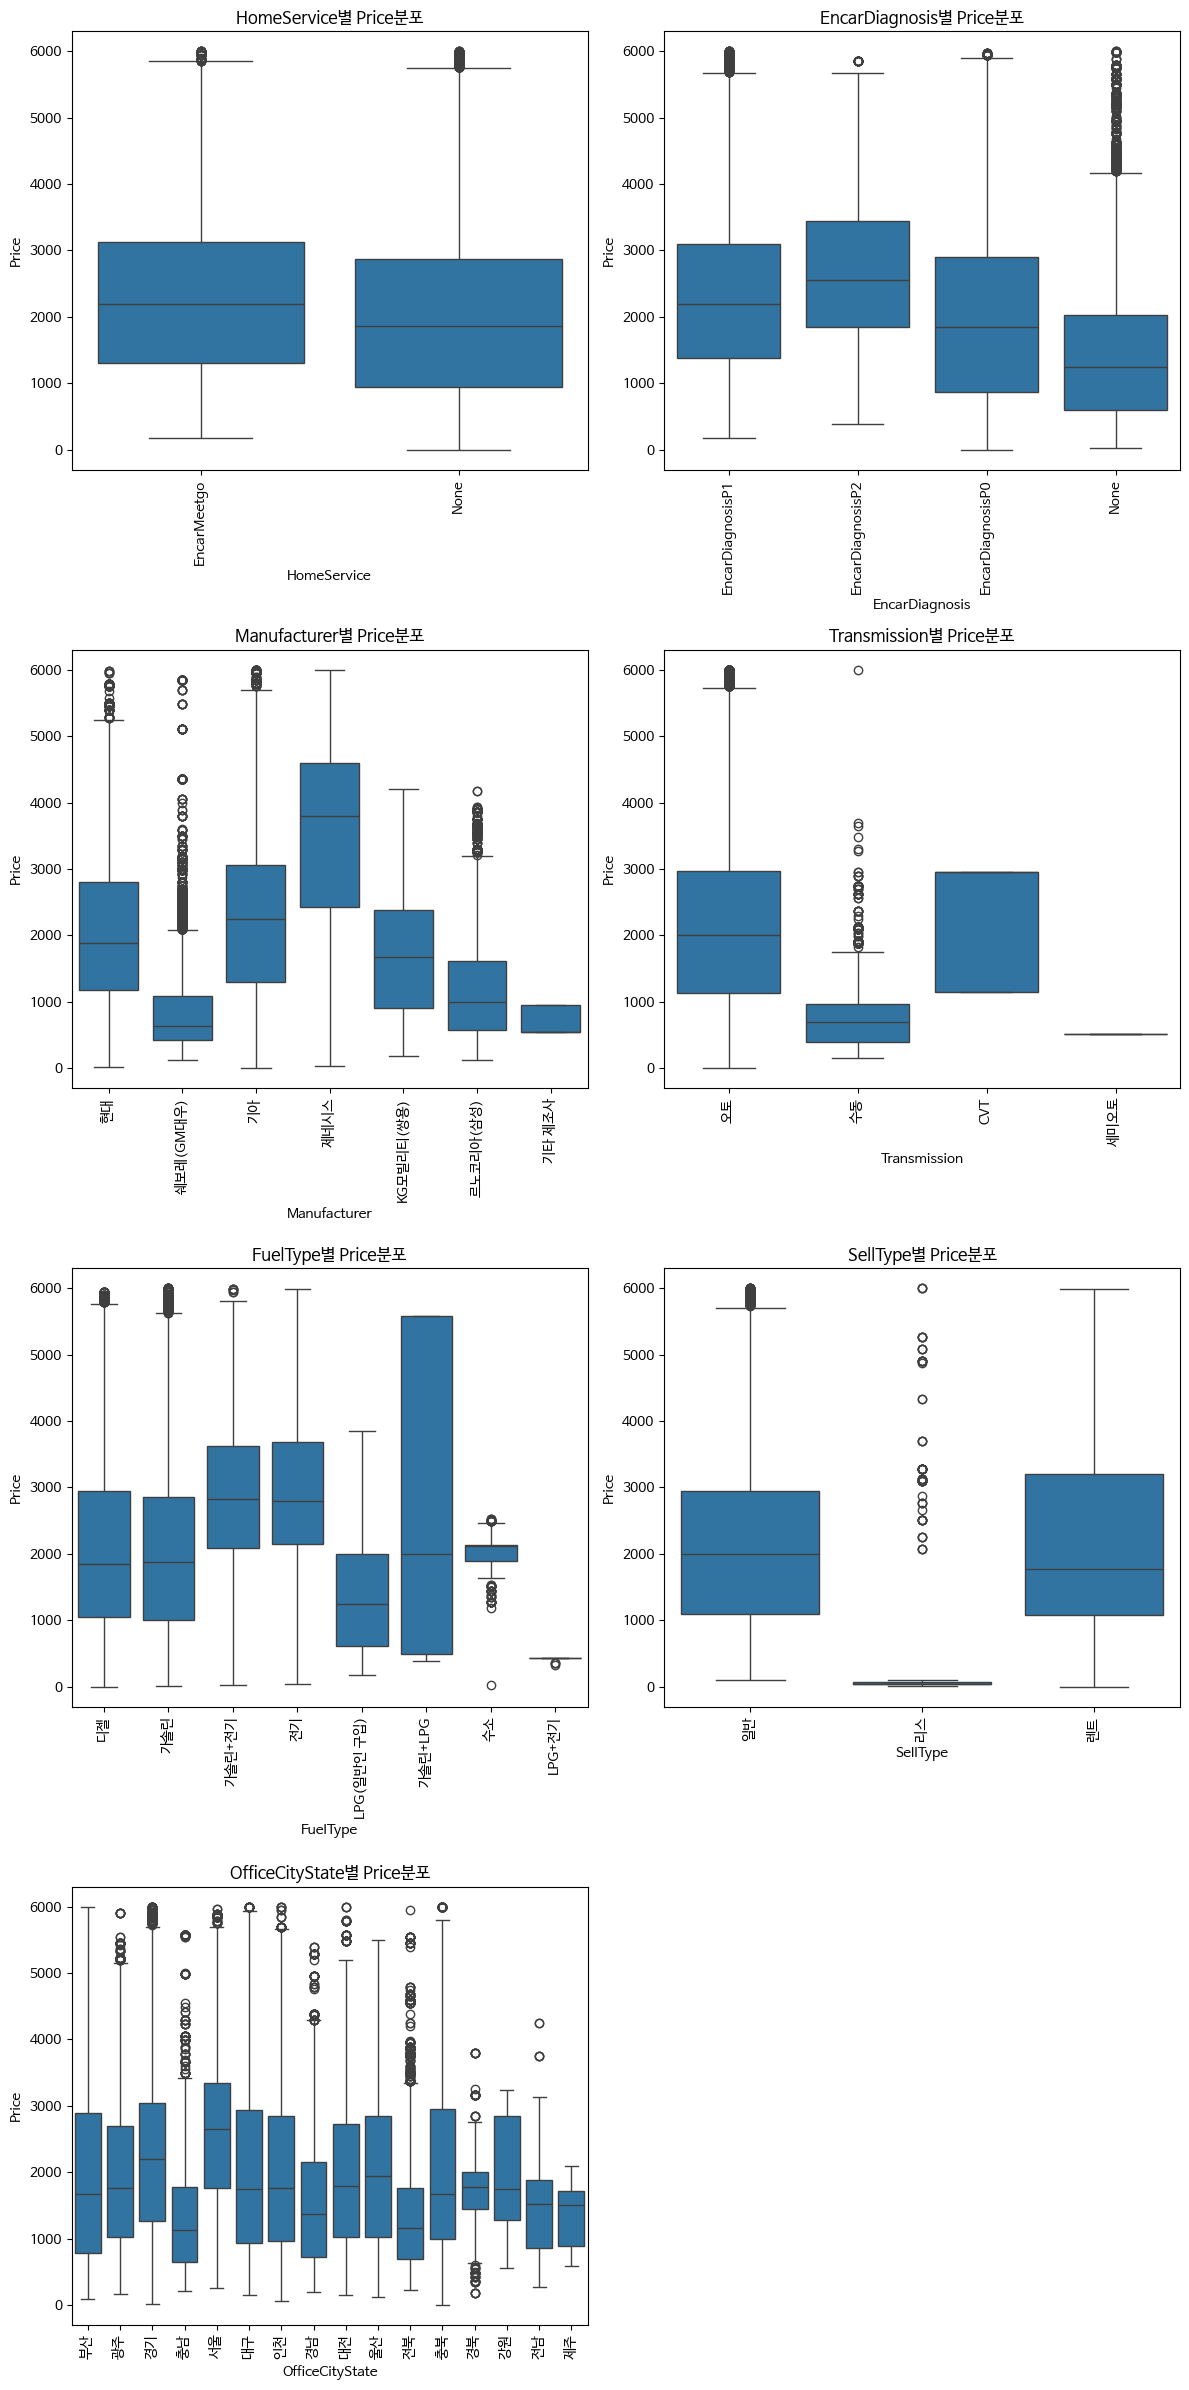

In [60]:
# boxplot을 다시 그려본다.

plt.figure(figsize=(12, 24))
for i, col in enumerate(['HomeService', 'EncarDiagnosis', 'Manufacturer', 'Transmission', 'FuelType', 'SellType', 'OfficeCityState']):
    plt.subplot(4, 2, i+1)
    ax = sns.boxplot(data=df_clean, x=col, y='Price')
    ax.set_title(f'{col}별 Price분포')
    ax.set_label(col)
    plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

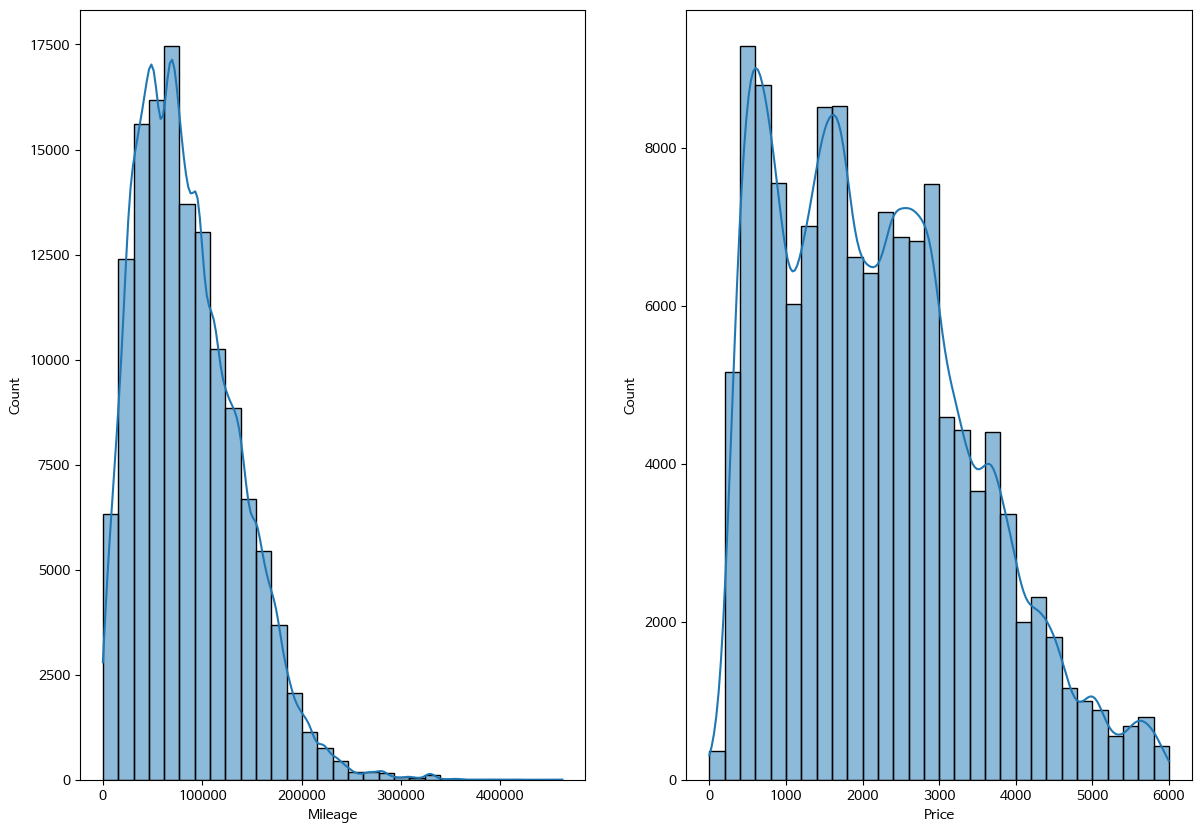

In [61]:
plt.figure(figsize=(30, 10))
for i, col in enumerate(['Mileage', 'Price']):
    plt.subplot(1, 4, i + 1)
    ax = sns.histplot(data=df_clean, x=col, bins=30, kde=True, fill=True)

# Mileage는 오른쪽으로 꼬리가 긴 분포를 가진다. sqrt 변환을 수행한다.
# Price

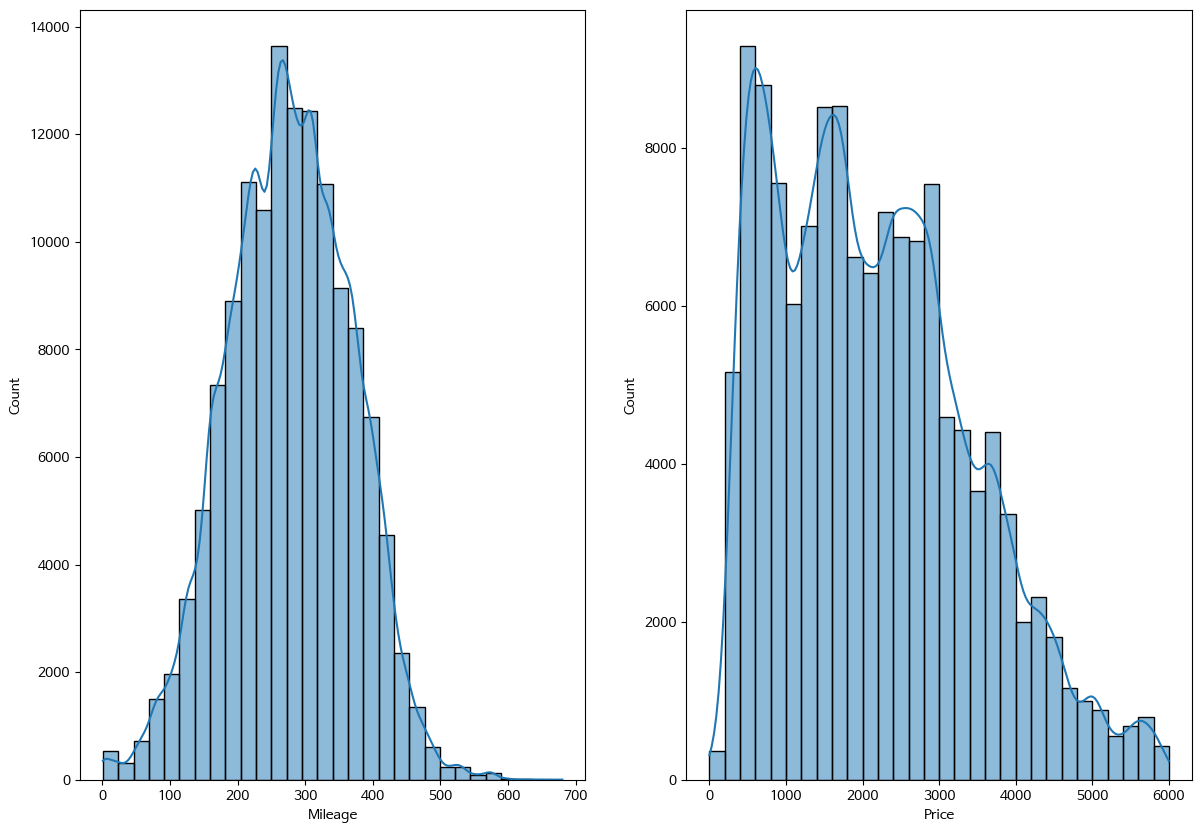

In [62]:
df_copy = df_clean.copy()
df_copy['Mileage'] = np.sqrt(df_copy['Mileage']) # ==== Feature Engineering ====

plt.figure(figsize=(30, 10))
for i, col in enumerate(['Mileage', 'Price']):
    plt.subplot(1, 4, i + 1)
    ax = sns.histplot(data=df_copy, x=col, bins=30, kde=True, fill=True)


In [63]:
df_copy['Year'] = df_copy['Year'].astype('int')
df_copy['Year'] = df_copy['Year'].astype('str') # ==== Feature Engineering ====(nonpipeline)
df_copy['Model_Year'] = df_copy['Year'].apply(lambda x: x[:4]).astype(int) # ==== Feature Engineering ====(nonpipeline)
df_copy['Model_Month'] = df_copy['Year'].apply(lambda x: x[4:]).astype(int) # === Feature Engineering ===(nonpipeline)
df_copy['Vehicle_Age'] = 2026 - df_copy['Model_Year'] # === Feature Engineering ===(nonpipeline)
df_copy.drop(['Year'], axis=1, inplace=True)
df_copy.drop(['Model_Year'], axis=1, inplace=True) # ==== Feature Enginnering ====(nonpipeline)

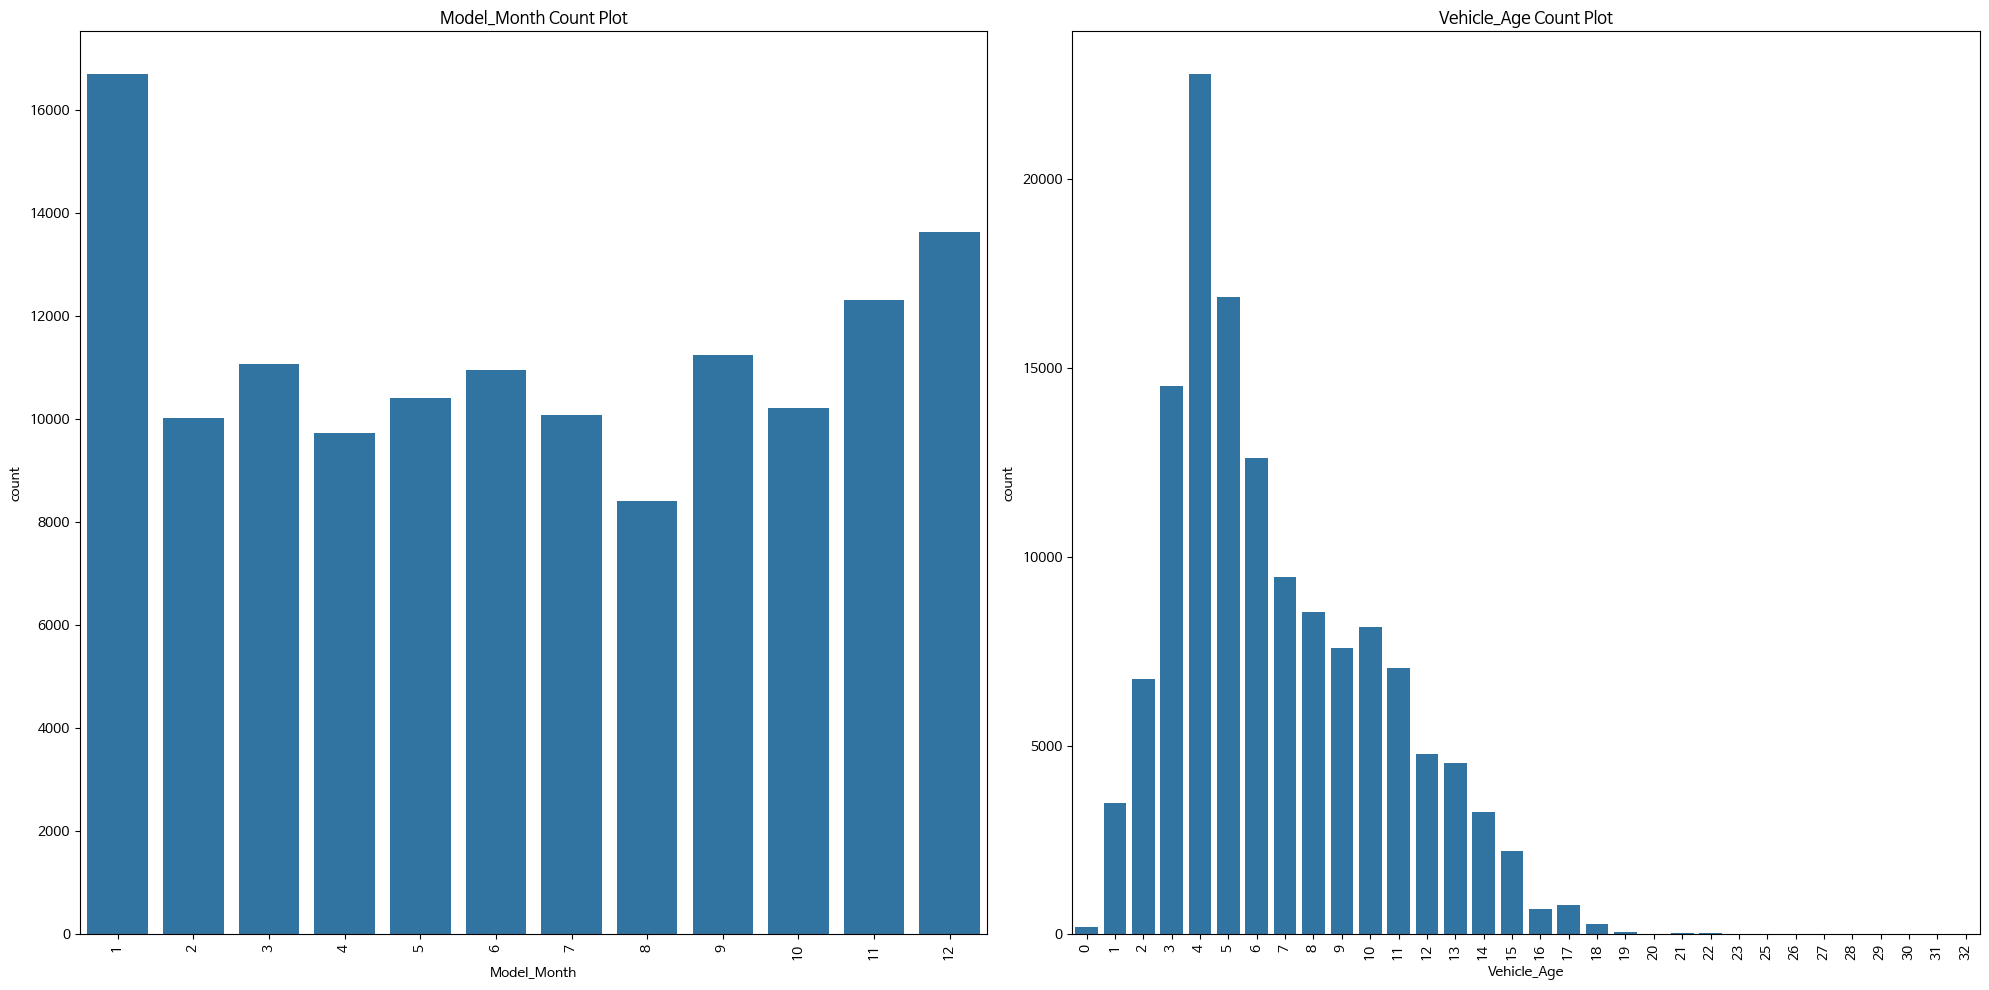

In [64]:
# Year와 Month별 countplot
plt.figure(figsize=(20, 10))
for i, col in enumerate(['Model_Month', 'Vehicle_Age']):
    plt.subplot(1, 2, i+1)
    ax = sns.countplot(data=df_copy, x=col)
    ax.set_title(f'{col} Count Plot')
    ax.set_xlabel(col)
    plt.xticks(rotation=90)
    
plt.tight_layout()
plt.show()

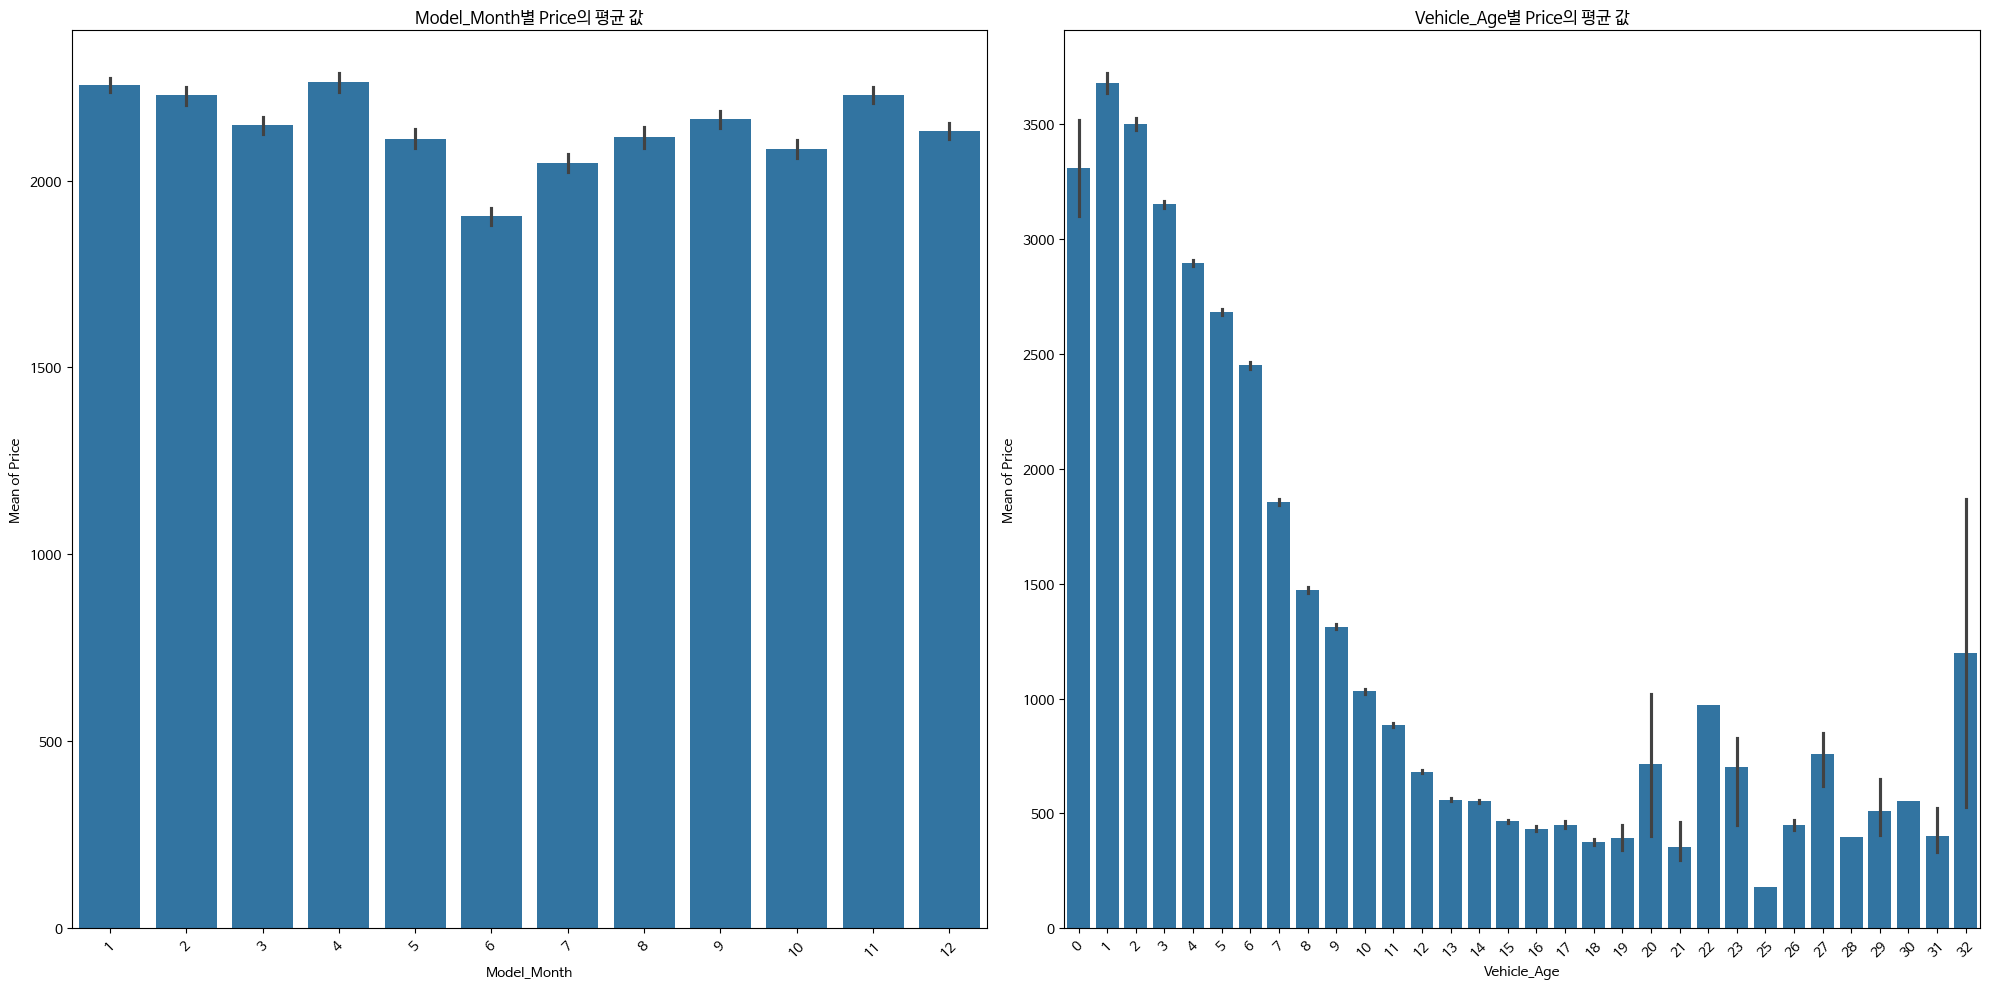

In [65]:
plt.figure(figsize=(20, 10))

for i, col in enumerate(['Model_Month', 'Vehicle_Age']):
    plt.subplot(1, 2, i+1)
    ax = sns.barplot(data=df_copy, x=col, y='Price')
    ax.set_title(f'{col}별 Price의 평균 값')
    ax.set_xlabel(col)
    ax.set_ylabel('Mean of Price')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Numerical Column Correlation')

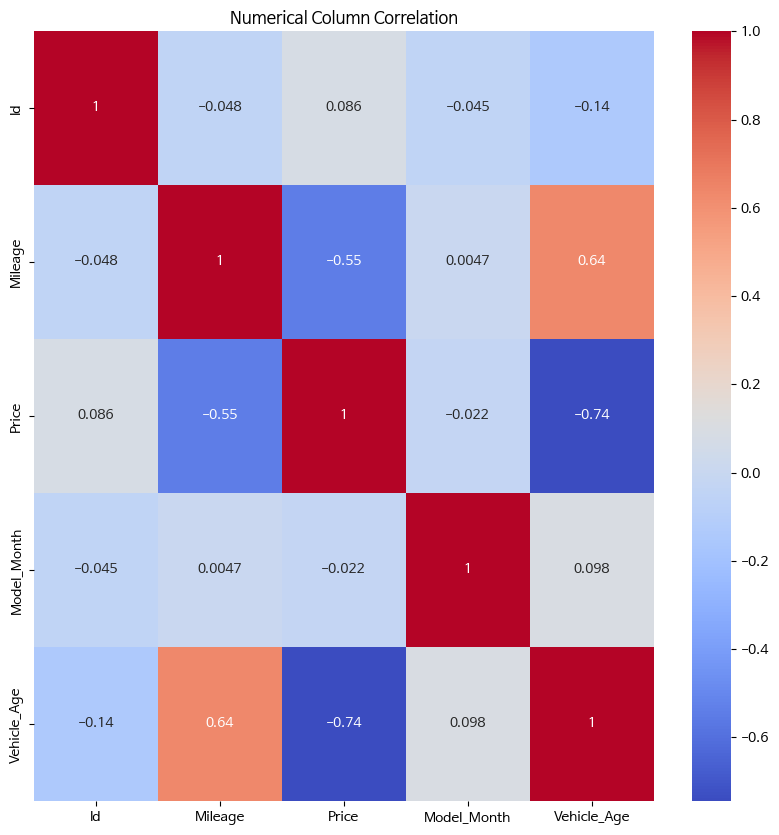

In [66]:
plt.figure(figsize=(10, 10))
corr = df_copy.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Numerical Column Correlation')

<Figure size 1000x1000 with 0 Axes>

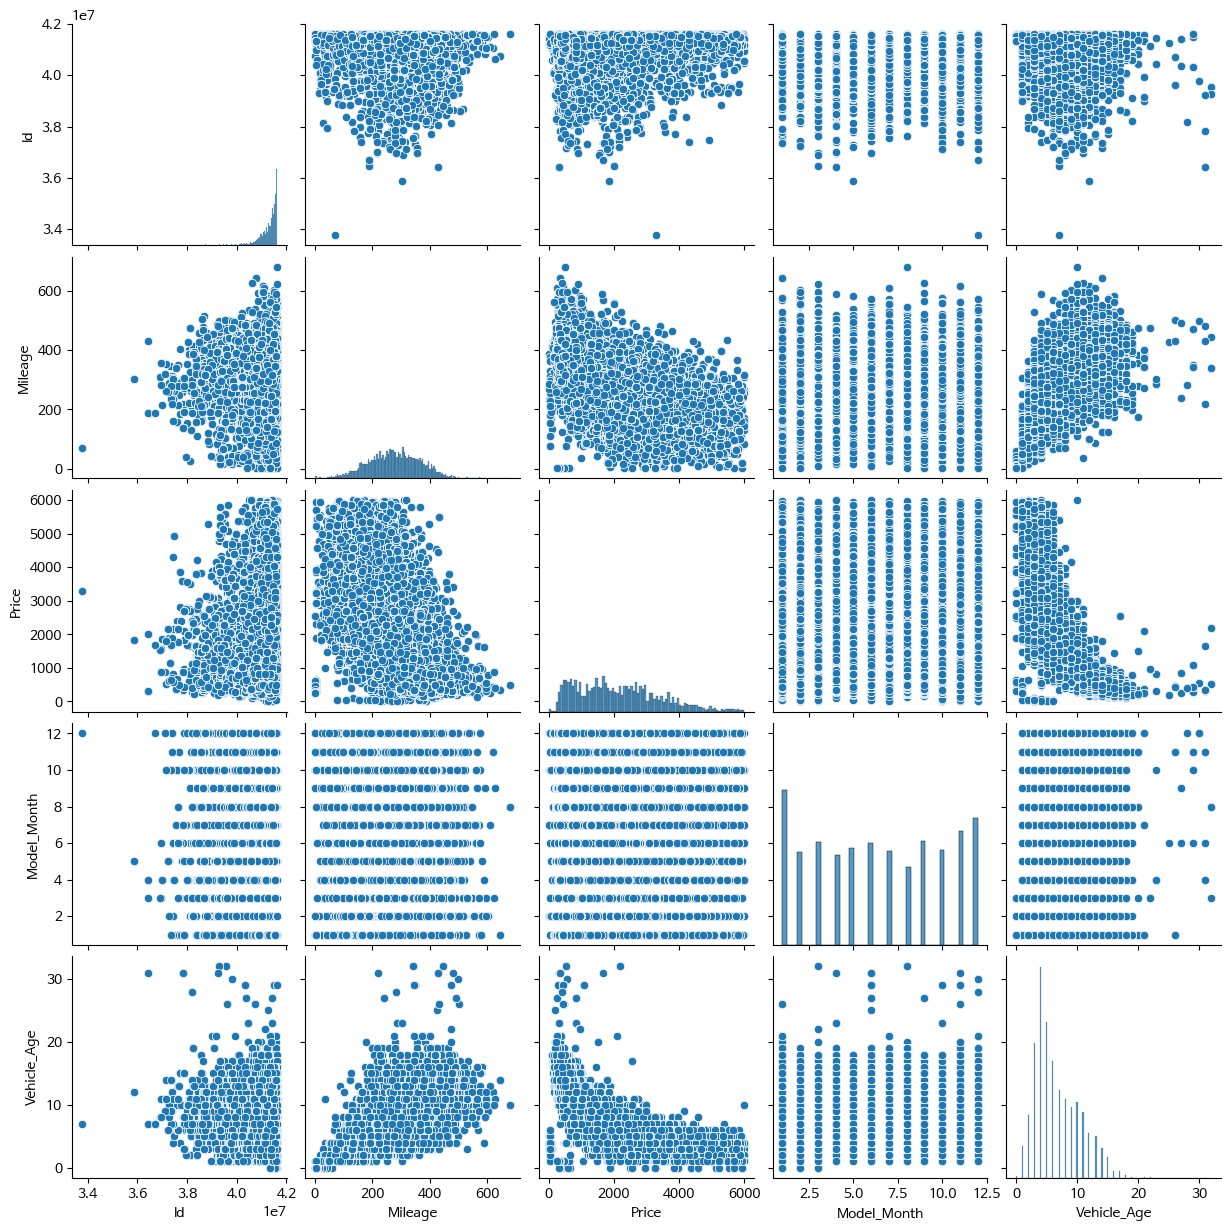

In [67]:
plt.figure(figsize=(10, 10))
sns.pairplot(data=df_copy)

In [68]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 134796 entries, 1 to 139019
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Id               134796 non-null  int64  
 1   HomeService      134796 non-null  object 
 2   EncarDiagnosis   134796 non-null  object 
 3   Manufacturer     134796 non-null  object 
 4   Model            134796 non-null  object 
 5   Badge            134796 non-null  object 
 6   Transmission     134796 non-null  object 
 7   FuelType         134796 non-null  object 
 8   Mileage          134796 non-null  float64
 9   Price            134796 non-null  float64
 10  SellType         134796 non-null  object 
 11  OfficeCityState  134796 non-null  object 
 12  Model_Month      134796 non-null  int64  
 13  Vehicle_Age      134796 non-null  int64  
dtypes: float64(2), int64(3), object(9)
memory usage: 15.4+ MB


In [69]:
# 선형 모델 테스트

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, ElasticNet, Ridge, Lasso
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer

X = df_copy.drop(['Id', 'Price'], axis=1)
y = df_copy['Price']

models = {
    'Ridge': Ridge(), 
    'LinearRegression': LinearRegression(), 
    'ElasticNet': ElasticNet(), 
    'Lasso': Lasso()
}

cat_pipe_impute = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')), 
    ('onehotencoder', OneHotEncoder()), 
])

cat_pipe_target_encode = Pipeline([
    ('targetencoder', TargetEncoder(categories='auto', target_type='continuous', smooth='auto'))
])

num_pipe = Pipeline([
    ('sqrtscaler', FunctionTransformer(np.sqrt, validate=True)), 
    ('stdscaler', StandardScaler())
])


transformer = ColumnTransformer([
    ('impute_onehot', cat_pipe_impute, ['HomeService', 'EncarDiagnosis']), 
    ('target_encoder', cat_pipe_target_encode, ['Manufacturer', 'Model', 'Badge', 'Transmission', 'FuelType', 'SellType', 'OfficeCityState']), 
    ('sqrt_std_scaler', num_pipe, ['Mileage'])
], 
    remainder='passthrough'
)

In [70]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

FOLD=3
metrics = pd.DataFrame(np.zeros((4, 3)), index=models.keys(), columns=['rmse_mean', 'mae_mean', 'r2_mean'])

for name, model in models.items():
    rmse_list = np.zeros(3)
    mae_list = np.zeros(3)
    r2_list = np.zeros(3)
    
    pipeline = Pipeline([
        ('preprocess', transformer), 
        (f'{name}', model)
    ])

    kfold = KFold(n_splits=FOLD, shuffle=True, random_state=42)
    for fold, (train_idx, valid_idx) in enumerate(kfold.split(X, y)):
        print(f'{fold}FOLD')
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        pipeline.fit(X_train, y_train)
        preds = pipeline.predict(X_valid)

        rmse = np.sqrt(mean_squared_error(y_valid, preds))
        rmse_list[fold] = rmse
        mae = mean_absolute_error(y_valid, preds)
        mae_list[fold] = mae
        r2 = r2_score(y_valid, preds)
        r2_list[fold] = r2

    metrics.loc[name, 'rmse_mean'] = rmse_list.mean()
    metrics.loc[name, 'mae_mean'] = mae_list.mean()
    metrics.loc[name, 'r2_mean'] = r2_list.mean()

0FOLD
1FOLD
2FOLD
0FOLD
1FOLD
2FOLD
0FOLD
1FOLD
2FOLD
0FOLD
1FOLD
2FOLD


In [71]:
metrics

,rmse_mean,mae_mean,r2_mean
Ridge,457.350486,311.136190,0.869703
LinearRegression,457.332391,311.150831,0.869714
ElasticNet,463.537331,318.901184,0.866154
Lasso,457.389886,311.114536,0.869681


In [72]:
# 트리 모델 테스트

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.preprocessing import LabelEncoder, TargetEncoder, StandardScaler, FunctionTransformer, OrdinalEncoder
from sklearn.impute import SimpleImputer

X = df_copy.drop(['Id', 'Price'], axis=1)
y = df_copy['Price']

models = {
    'RandomForestRegressor': RandomForestRegressor(), 
    'XGB': XGBRegressor(tree_method='hist', device='cuda'), 
    'LGBMRegressor': LGBMRegressor(device='gpu'), 
    'CatBoostRegressor': CatBoostRegressor(task_type='GPU', devices='0', verbose=0)
}

cat_pipe_impute = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')), 
    ('labelencoder', OrdinalEncoder()), 
])

cat_pipe_target_encode = Pipeline([
    ('targetencoder', TargetEncoder(categories='auto', target_type='continuous', smooth='auto'))
])

num_pipe = Pipeline([
    ('sqrtscaler', FunctionTransformer(np.sqrt, validate=True)), 
    ('stdscaler', StandardScaler())
])


transformer = ColumnTransformer([
    ('impute_onehot', cat_pipe_impute, ['HomeService', 'EncarDiagnosis']), 
    ('target_encoder', cat_pipe_target_encode, ['Manufacturer', 'Model', 'Badge', 'Transmission', 'FuelType', 'SellType', 'OfficeCityState']), 
    ('sqrt_std_scaler', num_pipe, ['Mileage'])
], 
    remainder='passthrough'
)

In [73]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

FOLD=3
metrics = pd.DataFrame(np.zeros((4, 3)), index=models.keys(), columns=['rmse_mean', 'mae_mean', 'r2_mean'])

for name, model in models.items():
    rmse_list = np.zeros(3)
    mae_list = np.zeros(3)
    r2_list = np.zeros(3)
    
    pipeline = Pipeline([
        ('preprocess', transformer), 
        (f'{name}', model)
    ])

    kfold = KFold(n_splits=FOLD, shuffle=True, random_state=42)
    for fold, (train_idx, valid_idx) in enumerate(kfold.split(X, y)):
        print(f'{fold}FOLD')
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        pipeline.fit(X_train, y_train)
        preds = pipeline.predict(X_valid)

        rmse = np.sqrt(mean_squared_error(y_valid, preds))
        rmse_list[fold] = rmse
        mae = mean_absolute_error(y_valid, preds)
        mae_list[fold] = mae
        r2 = r2_score(y_valid, preds)
        r2_list[fold] = r2

    metrics.loc[name, 'rmse_mean'] = rmse_list.mean()
    metrics.loc[name, 'mae_mean'] = mae_list.mean()
    metrics.loc[name, 'r2_mean'] = r2_list.mean()

0FOLD
1FOLD
2FOLD
0FOLD
1FOLD
2FOLD
0FOLD
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 994
[LightGBM] [Info] Number of data points in the train set: 89864, number of used features: 12
[LightGBM] [Info] Using GPU Device: Tesla P100-PCIE-16GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 12 dense feature groups (1.03 MB) transferred to GPU in 0.001906 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score 2142.487181
1FOLD
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 996
[LightGBM] [Info] Number of data points in the train set: 89864, number of used features: 12
[LightGBM] [Info] Using GPU Device: Tesla P100-PCIE-16GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 12 dense feature groups (1.03 MB) transferred to GPU in 0.001869 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score 2148.761295
2FOLD
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 994
[LightGBM] [Info] Number of data points in the train set: 89864, nu

In [74]:
metrics
# 선형 모델 보다는 확실히 성능이 좋아보인다. 하지만 r2점수가 0.99와 같이 압도적으로 높게 나와버린다면, 변수가 많은 중고차 예측 프로젝트 같은 경우에는 과적합 위험이 있기 때문에
# 적당한 rmse_score와 적당한 mae_mean, 적당한 r2_mean을 가진 LGBMRegressor를 최종 모델로 선택하고 optuna라이브러리를 활용해 최적의 파라미터를 구한다.

,rmse_mean,mae_mean,r2_mean
RandomForestRegressor,99.093685,23.034485,0.993797
XGB,176.671171,111.519368,0.980542
LGBMRegressor,240.679324,165.850805,0.963907
CatBoostRegressor,201.422183,133.119528,0.974724


In [75]:
df_copy

,Id,HomeService,EncarDiagnosis,Manufacturer,Model,Badge,Transmission,FuelType,Mileage,Price,SellType,OfficeCityState,Model_Month,Vehicle_Age
1,40929662,EncarMeetgo,EncarDiagnosisP1,현대,스타리아,Others,오토,디젤,68.036755,4290.0,일반,부산,10,3
2,41593118,EncarMeetgo,EncarDiagnosisP1,쉐보레(GM대우),Others,LS,오토,가솔린,192.950771,400.0,일반,부산,7,12
3,40596394,EncarMeetgo,EncarDiagnosisP1,쉐보레(GM대우),올 뉴 말리부,Others,오토,가솔린,354.921118,850.0,일반,광주,11,10
4,41252502,EncarMeetgo,EncarDiagnosisP1,현대,그랜드 스타렉스,11인승 왜건,오토,디젤,403.081878,990.0,일반,광주,9,11
5,41409213,EncarMeetgo,EncarDiagnosisP1,현대,투싼 하이브리드 (NX4),인스퍼레이션 2WD,오토,가솔린+전기,281.300551,2700.0,일반,광주,12,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139015,41355607,None,EncarDiagnosisP0,현대,그랜저 HG,Others,오토,가솔린,399.588538,830.0,일반,부산,6,12
139016,41525043,None,EncarDiagnosisP0,쉐보레(GM대우),스파크,LS,수동,가솔린,346.387067,350.0,일반,부산,4,14
139017,41583677,None,EncarDiagnosisP1,현대,그랜저 HG,Others,오토,가솔린,381.232213,500.0,일반,부산,6,14
139018,40778645,None,EncarDiagnosisP1,르노코리아(삼성),QM6,Others,오토,가솔린,339.638043,1290.0,일반,부산,12,9


In [76]:
# 최적 모델 선정 후 optuna활용(최적 모델은 LGBMRegressor)
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from lightgbm import LGBMRegressor

X = df_copy.drop(['Id', 'Price'], axis=1)
y = df_copy['Price']

cat_pipe_impute = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')), 
    ('ordinalencoder', OrdinalEncoder()), 
])

cat_pipe_target_encode = Pipeline([
    ('targetencoder', TargetEncoder(categories='auto', target_type='continuous', smooth='auto'))
])

num_pipe = Pipeline([
    ('sqrtscaler', FunctionTransformer(np.sqrt, validate=True)), 
    ('stdscaler', StandardScaler())
])


transformer = ColumnTransformer([
    ('impute_ordinal', cat_pipe_impute, ['HomeService', 'EncarDiagnosis']), 
    ('target_encoder', cat_pipe_target_encode, ['Manufacturer', 'Model', 'Badge', 'Transmission', 'FuelType', 'SellType', 'OfficeCityState']), 
    ('sqrt_std_scaler', num_pipe, ['Mileage'])
], 
    remainder='passthrough'
)


def objective(trial):
    params = {
        'objective': 'regression', 
        'metric': 'rmse', 
        'verbosity': -1, 
        'boosting_type': 'gbdt', 
        'device': 'gpu', 
        'tree_method': 'hist', 
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True), # 학습률
        'n_estimators': trial.suggest_int('n_estimators', 500, 3000), # 트리의 개수
        'num_leaves': trial.suggest_int('num_leaves', 31, 256), # 하나의 트리가 가질 수 있는 최대 리프 개수
        'max_depth': trial.suggest_int('max_depth', 5, 15), # 트리의 최대 깊이
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100), # 리프 노드가 되기 위한 최소 데이터 수
        'subsample': trial.suggest_float('subsample', 0.6, 1.0), # 개별 트리 학습 시 무작위로 선택할 데이터 비율
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0), # 트리를 만들 때 선택할 피처
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True), # 규제
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True) # 규제
    }

    
    model = LGBMRegressor(**params)

    pipeline = Pipeline([
        ('preprocess', transformer), 
        ('model', model)
    ])

    # kfold = KFold(n_splits=FOLD, shuffle=True, random_state=42)
    # rmse_mean = -cross_val_score(pipeline, X, y, cv=kfold, scoring='neg_root_mean_squared_error', n_jobs=1).mean()
    
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, shuffle=True, test_size=0.3)
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_valid)
    rmse = np.sqrt(mean_squared_error(y_valid, preds))
    
    return rmse

In [77]:
import optuna

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

[I 2026-03-11 12:38:54,787] A new study created in memory with name: no-name-092e5e27-6d42-4fe1-9d6a-0cde3cecd446
[I 2026-03-11 12:39:14,824] Trial 0 finished with value: 216.08321868584224 and parameters: {'learning_rate': 0.005449655837131574, 'n_estimators': 2967, 'num_leaves': 39, 'max_depth': 8, 'min_child_samples': 85, 'subsample': 0.6994728043233557, 'colsample_bytree': 0.9121345919799368, 'reg_alpha': 0.018621696911173755, 'reg_lambda': 2.5086356321146538e-08}. Best is trial 0 with value: 216.08321868584224.
[I 2026-03-11 12:39:32,722] Trial 1 finished with value: 166.2640538428622 and parameters: {'learning_rate': 0.012131265941182637, 'n_estimators': 1783, 'num_leaves': 230, 'max_depth': 7, 'min_child_samples': 17, 'subsample': 0.6835000529415121, 'colsample_bytree': 0.8168566885987926, 'reg_alpha': 3.067170312755989e-06, 'reg_lambda': 0.006539176442588266}. Best is trial 1 with value: 166.2640538428622.
[I 2026-03-11 12:40:03,747] Trial 2 finished with value: 145.41034080406

In [78]:
final_model = LGBMRegressor( 
    objective = 'regression', 
    metric = 'rmse', 
    verbosity = -1, 
    boosting_type = 'gbdt', 
    device = 'gpu', 
    tree_method = 'hist', 
    **study.best_params
)

pipeline = Pipeline([
    ('preprocess', transformer), 
    ('model', final_model)
])

X_train, X_valid, y_train, y_valid = train_test_split(X, y, shuffle=True, random_state=42, test_size = 0.2)


pipeline.fit(X_train, y_train)
preds = pipeline.predict(X_valid)

rmse = np.sqrt(mean_squared_error(y_valid, preds))
mae = mean_absolute_error(y_valid, preds)
r2 = r2_score(y_valid, preds)

print('rmse : ', rmse)
print('mae : ', mae)
print('r2 : ', r2)

rmse :  100.31158333232099
mae :  40.750822814051354
r2 :  0.9937913094015123


In [79]:
# 최종 모델 학습
final_model = LGBMRegressor( 
    objective = 'regression', 
    metric = 'rmse', 
    verbosity = -1, 
    boosting_type = 'gbdt', 
    device = 'gpu', 
    tree_method = 'hist', 
    **study.best_params
)

pipeline = Pipeline([
    ('preprocess', transformer), 
    ('model', final_model)
])

pipeline.fit(X, y)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('impute_ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='None',
                                                                                 strategy='constant')),
                                                                  ('ordinalencoder',
                                                                   OrdinalEncoder())]),
                                                  ['HomeService',
                                                   'EncarDiagnosis']),
                                                 ('target_encoder',
                                                  Pipeline(steps=[('targetencoder',
                                                                   TargetEncoder(target_type='continuous'))])...
                                                  ['Mileage'])])),
                ('model',
                 LGBMRegressor(colsample_bytree=0.9252100908133132,
                               device='gpu', learning_rate=0.06185901961796085,
                               max_depth=13, metric='rmse',
                               min_child_samples=40, n_estimators=2241,
                               num_leaves=159, objective='regression',
                               reg_alpha=0.7672276276992762,
                               reg_lambda=2.1604235843724536e-06,
                               subsample=0.8886408504077595, tree_method='hist',
                               verbosity=-1))])

In [80]:
rare_label_index

{'Badge': Index(['1.6 디젤 LTZ', '스탠다드', '1.6 디젤 LT', '2.0 HEV', '3.3T 스포츠 AWD',
        '가솔린 2WD RE', 'PE', 'LPI 디럭스', '4WD RX4', 'HG240 럭셔리',
        ...
        '1.6 디젤 프레스티지', 'LIMITED 리무진 9인승', 'SM520V 플러스', '2WD RS', '이동판매차',
        '3.6 익스트림 2WD', '디젤 1.6 2WD C7', '고급형', '1.6 터보 스타일', '3.3 GT 아크로 에디션'],
       dtype='object', name='Badge', length=915),
 'Model': Index(['i30 (PD)', '렉스턴 W', '슈퍼 렉스턴', '아베오 해치백', 'LF 쏘나타 하이브리드', '볼트 EV',
        '더 뉴 캐스퍼', '스팅어 마이스터', 'i30(신형)', 'K5 하이브리드',
        ...
        '로체 어드밴스', '뉴SM5', '라세티 프리미어', '더 뉴 아베오 해치백', 'NF 쏘나타 트랜스폼', '뉴무쏘',
        'NF 쏘나타', '더 뉴 쏘울', '그랜드 카니발', '마티즈 클래식'],
       dtype='object', name='Model', length=171)}

In [81]:
# 최종 모델 및 전처리기, 희소 라벨을 걸러낼 수 있는 상위 카테고리들 저장.
import joblib

joblib.dump(pipeline, 'final_model.pkl')

['final_model.pkl']

In [82]:
badge_count = df['Badge'].value_counts()
rare_label_dict = {}
rare_label_dict['Badge'] = badge_count[badge_count.index != 'Others'].index.tolist()
model_counts = df['Model'].value_counts()
rare_label_dict['Model'] = model_counts[model_counts.index != 'Others'].index.tolist()
rare_label_dict
joblib.dump(rare_label_dict, 'rare_label_dict.pkl')

['rare_label_dict.pkl']

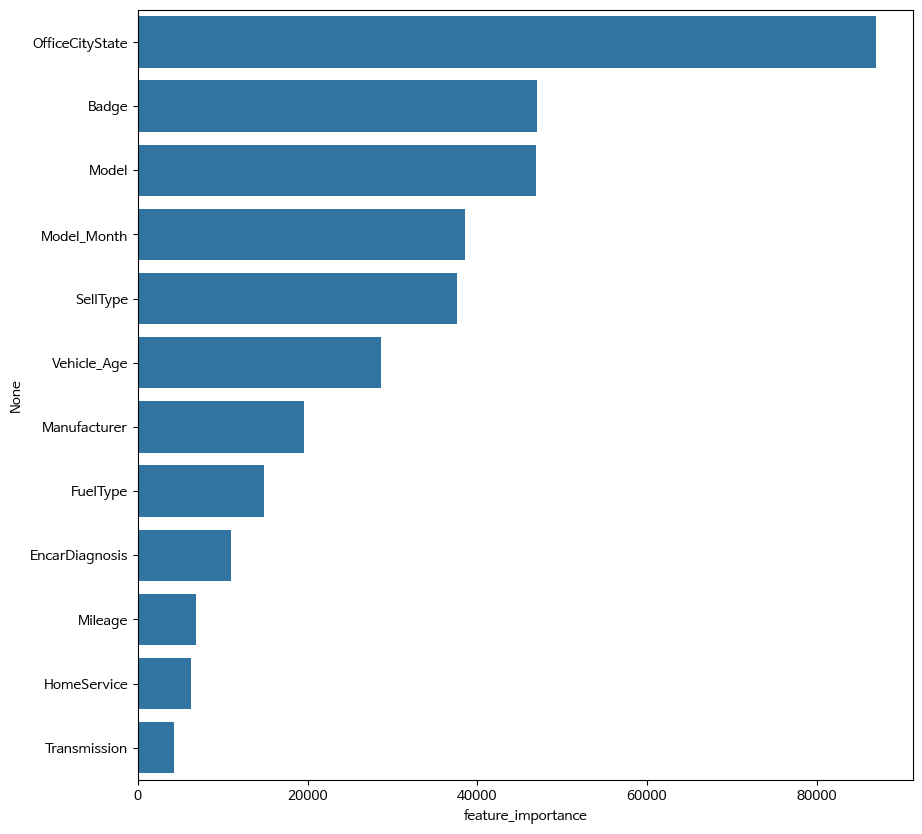

In [131]:
# Feature Importance


feature_importances = pipeline['model'].feature_importances_
feature_names = pipeline['preprocess'].feature_names_in_

feature_df = pd.DataFrame(np.zeros((len(feature_names), 1)), index = feature_names, columns=['feature_importance'])
feature_df['feature_importance'] = feature_importances
feature_df = feature_df.sort_values(by='feature_importance', ascending=False)

plt.figure(figsize=(10, 10))
ax = sns.barplot(data=feature_df, y=feature_df.index, x='feature_importance')